<a href="https://colab.research.google.com/github/Kaveh-Ramezani/202610ELC536501/blob/main/3/FuncAppr_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch + Tanh Prime + Gaussian Mixture Model (GMM)

### 0.  The first imports

In [219]:
# PyTorch
import torch
import torch.nn as nn
# General
import numpy as np
import matplotlib.pyplot as plt

### 1. The 2D function to be modeled

In [ ]:
#The 2D function that is to be modeled
def F_mv(x1,x2):
    return np.exp(-x1**2-x2**2) # Gaussian Mixture Model (GMM)

### 2. Activation Functions

In [221]:
def Tanh(x):
    return torch.tanh(x) # (PyTorch version)
def Tanh_prime(x):
    return 1.0 - torch.tanh(x)**2 # (PyTorch version)

ActivationFunction = Tanh_prime

### 3. Visualization of the target function, functions



In [222]:
def visualize_original(Width,Height,U,V):
    H2 = np.empty((Height,Width))
    for i in range(Width):
        u = U * ((i - Width/2.0) / (Width/2.0))
        for j in range(Height):
            v = V *((j - Height/2.0) / (Height/2.0))
            H2[j,i] = F_mv(u,v)  #The 2D func

    return H2

### 4. Visualize modeled functions

In [223]:
def visualize_2layer(Width,Height,model,U,V):
    ret = np.empty((Height,Width))
    for i in range(Width):
        u = U * ((i - Width/2.0) / (Width/2.0))
        for j in range(Height):
            v = V *((j - Height/2.0) / (Height/2.0))
            x = [u,v]
            ret[j,i] = model(torch.from_numpy(np.array(x)).float()).item()
    return ret

### 5. Generating Training Data

In [224]:
#Generate training data
A = 2
nb_samples = 1000
F = F_mv
X_train = np.random.uniform(-A,A,(nb_samples,2))

Y_train = np.zeros(shape=(nb_samples,1))

for i in range(nb_samples):
    Y_train[i] = [F(X_train[i][0],X_train[i][1])]


### 6. Making the nural network

In [225]:
#Two-Layer Neural Network Structure
N1 = 20  #Number of neurons in the hidden layer

class Model(nn.Module):
    def __init__(self,n_input,n_hidden,n_output):
        super(Model, self).__init__()
        self.W1 = nn.Parameter(torch.randn(n_input,n_hidden)*np.sqrt(6/(n_input+n_hidden)))
        self.b1 = nn.Parameter(torch.zeros(n_hidden))
        self.W2 = nn.Parameter(torch.randn(n_hidden,n_output)*np.sqrt(6/(n_hidden+n_output)))
        self.b2 = nn.Parameter(torch.zeros(n_output))

    def forward(self,x):
        h1 = ActivationFunction(x @ self.W1 + self.b1)
        h2 = h1 @ self.W2 + self.b2
        return h2
model = Model(2, N1, 1)

### 7. Optimization

In [226]:
#Optimization
eta =1e-3

criteration = nn.MSELoss() # The loss function is the Mean Squared Error (MSE)
optimizer = torch.optim.SGD(model.parameters(), lr=eta)

num_epochs = int(1e5)
epochs_between_two_evaluations = int(num_epochs/10)
batch_size = 100
loss_history = []

X_train = torch.from_numpy(X_train).float()
Y_train = torch.from_numpy(Y_train).float()

for epoch in range(num_epochs):
    output = model(X_train)
    loss = criteration(output, Y_train)
    
    loss.backward()
    optimizer.step()

    optimizer.zero_grad()
    
    loss_history.append(loss.item())
    
    if (epoch+1) % epochs_between_two_evaluations == 0:
        with torch.no_grad():
            curr_loss = criteration(output, Y_train)
            print(f'epoch: {epoch+1}, loss: {curr_loss.item():.4f}')

epoch: 10000, loss: 0.0042
epoch: 20000, loss: 0.0026
epoch: 30000, loss: 0.0021
epoch: 40000, loss: 0.0018
epoch: 50000, loss: 0.0016
epoch: 60000, loss: 0.0015
epoch: 70000, loss: 0.0013
epoch: 80000, loss: 0.0012
epoch: 90000, loss: 0.0011
epoch: 100000, loss: 0.0010


### 8. Visualize Training Progress

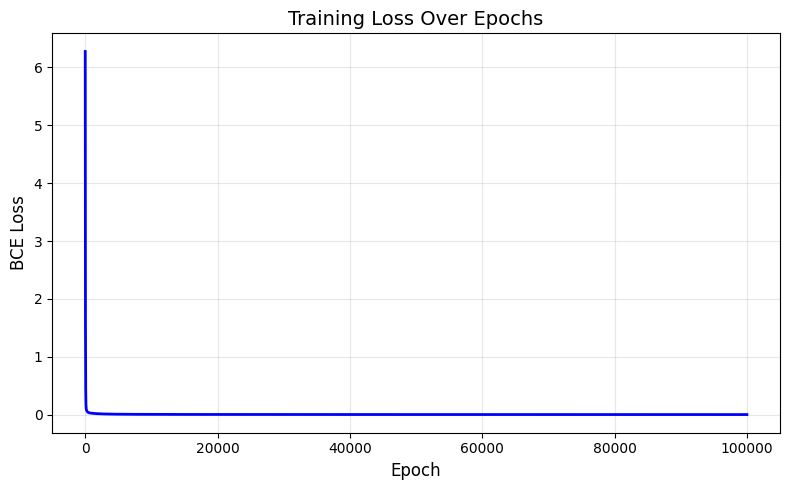

In [227]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), loss_history, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('BCE Loss', fontsize=12)
plt.title('Training Loss Over Epochs', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Visualization

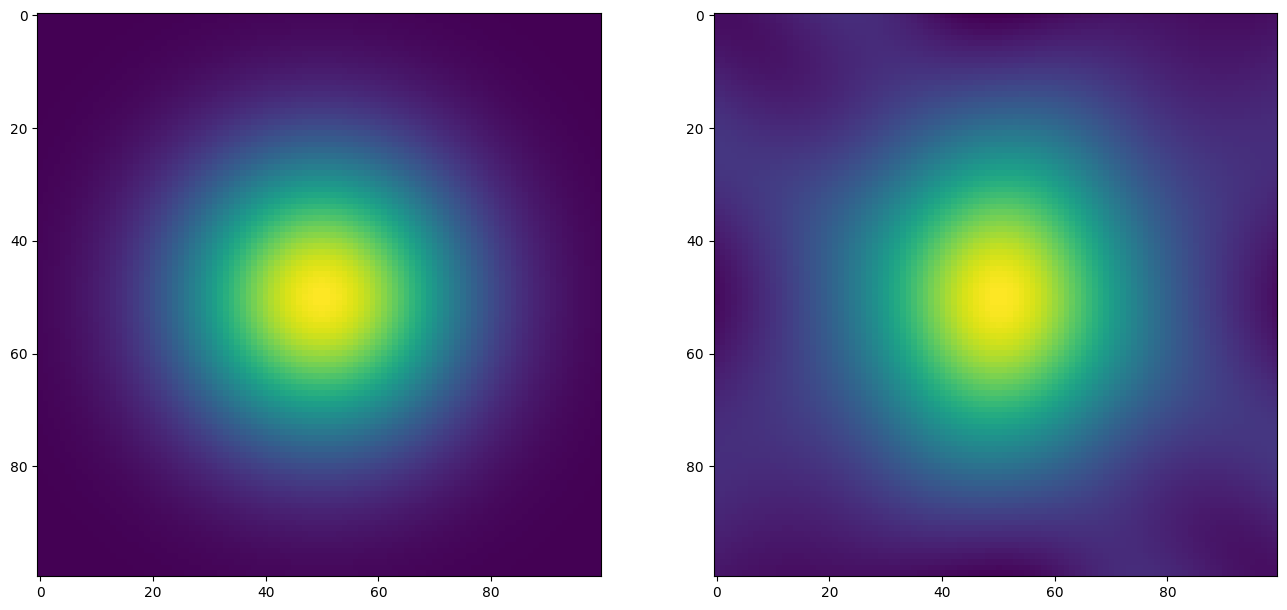

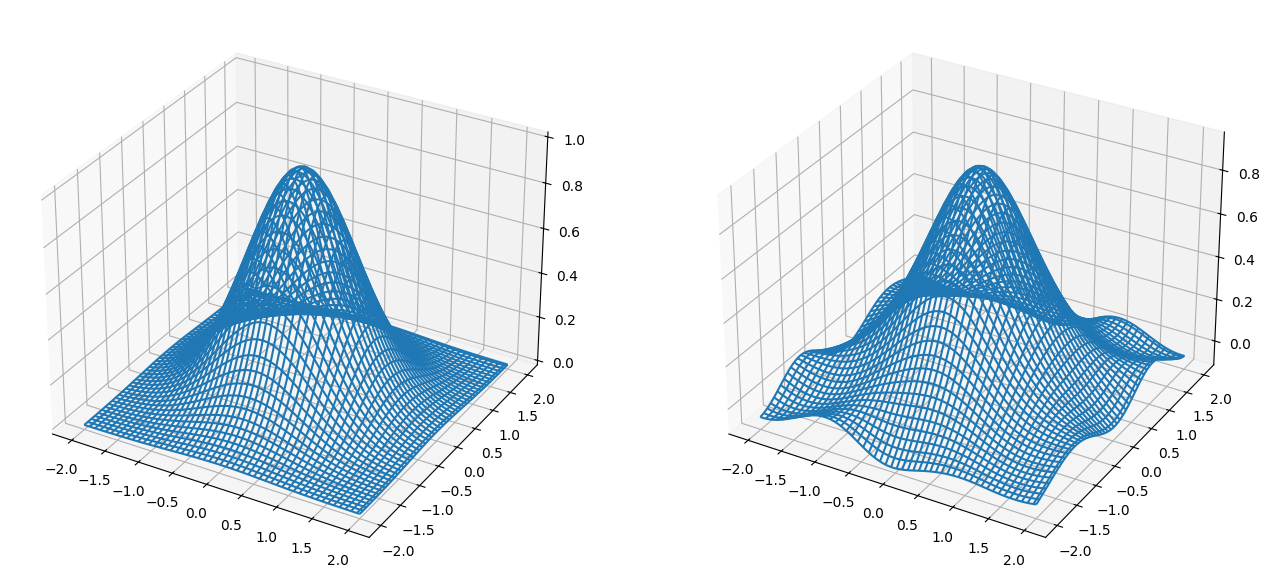

In [228]:
#Visualize the predicted function
I_original = visualize_original(100,100,A,A)

I = visualize_2layer(100,100,model,U=A,V=A)

f = plt.figure(figsize=(16, 8))

f.add_subplot(1,2, 1)
plt.imshow(I_original)
f.add_subplot(1,2, 2)
plt.imshow(I)
plt.show(block=True)

x = np.linspace(-A, A, 100)
y = np.linspace(-A, A, 100)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(121,projection='3d')
ax1.plot_wireframe(X, Y, I_original)
ax2 = fig.add_subplot(122,projection='3d')
ax2.plot_wireframe(X, Y, I)